In [22]:
import os
import re
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

## ENERGIJA

In [110]:
# ================= USER CONFIG =================
SIM_NAME   = "MW izolirana"     # npr. "MW", "MW + LMC", "Major merger"
DATA_DIR   = "MW"              # mapa kjer je energy.txt
# MW
# kroglasta/output2
# LMC
# trk

FIG_DIR    = "figs"            # kam shranjujemo PDF-je
# iz tvoje analize:
EKIN_COL = 15
EPOT_COL = 9
# ==============================================

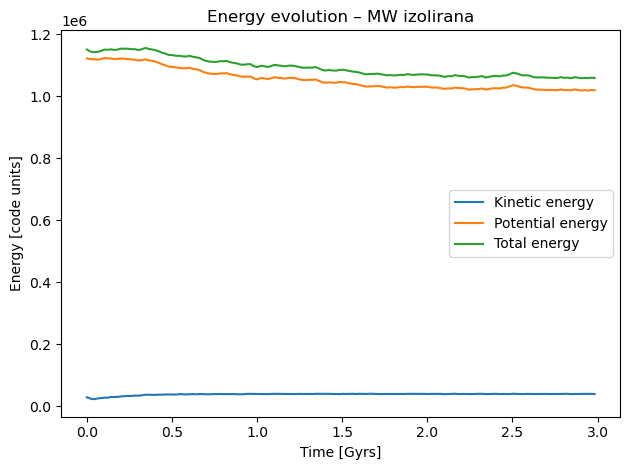

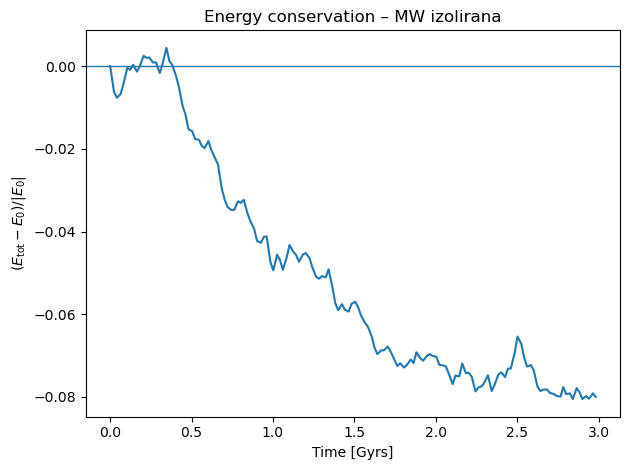

In [111]:
Path(FIG_DIR).mkdir(exist_ok=True)

energy_path = Path(DATA_DIR) / "energy.txt"
if not energy_path.exists():
    raise FileNotFoundError(f"energy.txt not found in {energy_path.resolve()}")

df = pd.read_csv(energy_path, delim_whitespace=True, header=None)

t = df.iloc[:, 0].to_numpy()
Ekin = df.iloc[:, EKIN_COL].to_numpy()
Epot = df.iloc[:, EPOT_COL].to_numpy()
Etot = Ekin + Epot   # robustna definicija

# ---------------- Energy evolution ----------------
plt.figure()
plt.plot(t, Ekin, label="Kinetic energy")
plt.plot(t, Epot, label="Potential energy")
plt.plot(t, Etot, label="Total energy")

plt.xlabel("Time [Gyrs]")
plt.ylabel("Energy [code units]")
plt.title(f"Energy evolution – {SIM_NAME}")
plt.legend()
plt.tight_layout()
plt.savefig(Path(FIG_DIR) / f"energy_{SIM_NAME.replace(' ', '_')}.pdf")
plt.show()

# ---------------- Energy drift ----------------
E0 = Etot[np.isfinite(Etot)][0]
drift = (Etot - E0) / abs(E0)

plt.figure()
plt.plot(t, drift)
plt.axhline(0, linewidth=1)
plt.xlabel("Time [Gyrs]")
plt.ylabel(r"$(E_{\rm tot}-E_0)/|E_0|$")
plt.title(f"Energy conservation – {SIM_NAME}")
plt.tight_layout()
plt.savefig(Path(FIG_DIR) / f"energy_drift_{SIM_NAME.replace(' ', '_')}.pdf")
plt.show()

## SFR

In [125]:
# ================= USER CONFIG =================
SIM_NAME = "MW + LMC"
DATA_DIR = "LMC" 
# MW
# kroglasta/output2
# LMC
# trk

FIG_DIR  = "figs"

WINDOW = 10
# ==============================================

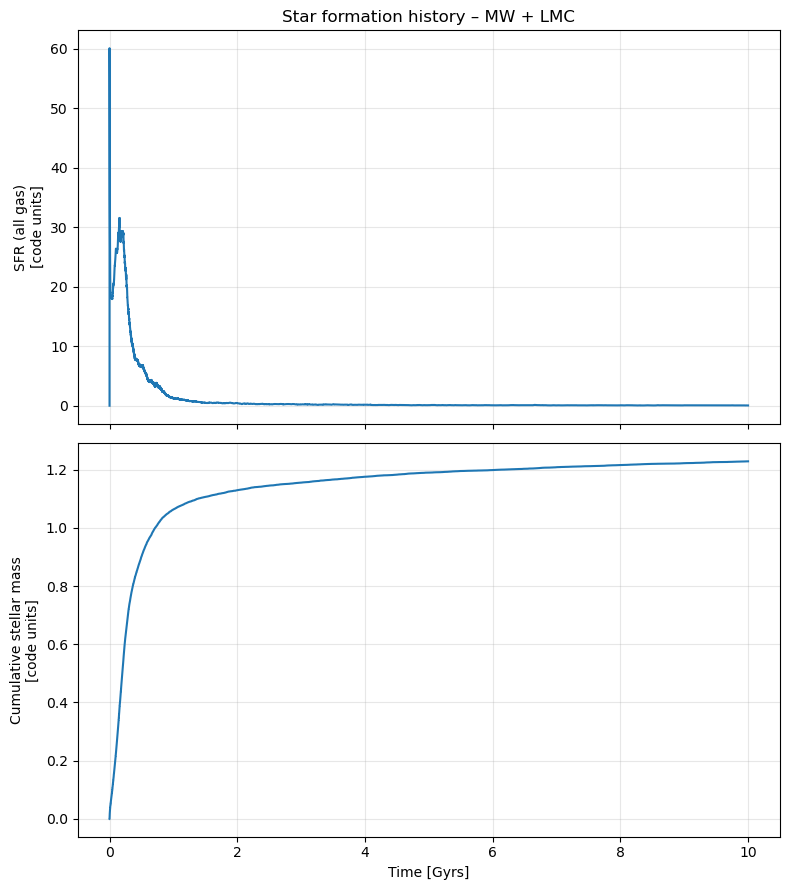

Saved: /home/jurijs/Documents/Faks/ZDZ/dn3/figs/sfr_3panel_smoothed_MW_+_LMC.pdf


In [126]:
Path(FIG_DIR).mkdir(exist_ok=True)

sfr_path = Path(DATA_DIR) / "sfr.txt"
df = pd.read_csv(sfr_path, delim_whitespace=True, header=None)

t = df.iloc[:, 0].to_numpy()
sfr_all = df.iloc[:, 2].to_numpy()
cum_mass = df.iloc[:, 5].to_numpy()


# -------- plotting --------
fig, axes = plt.subplots(
    nrows=2, ncols=1, sharex=True,
    figsize=(8, 9)
)

# (1) SFR all gas
axes[0].plot(t, sfr_all)
axes[0].set_ylabel("SFR (all gas)\n[code units]")
axes[0].set_title(f"Star formation history – {SIM_NAME}")


# (3) Cumulative formed stellar mass
axes[1].plot(t, cum_mass)
axes[1].set_ylabel("Cumulative stellar mass\n[code units]")
axes[1].set_xlabel("Time [Gyrs]")

for ax in axes:
    ax.grid(True, alpha=0.3)

plt.tight_layout()
outfile = Path(FIG_DIR) / f"sfr_3panel_smoothed_{SIM_NAME.replace(' ', '_')}.pdf"
plt.savefig(outfile)
plt.show()

print("Saved:", outfile.resolve())